# Assessment Overview

APM1220: Applied Multivariate Data Analysis
Formative Assessment 4

## 1. Hotelling's $T^2$ Test for a Mean Vector

**Hypothesis:**
$H_0: \mu' = [7, 11]$
$H_1: \mu' \neq [7, 11]$

**(a) Evaluation of $T^2$:**
Given the data matrix $X$, the sample mean vector is $\bar{X} = [6, 10]'$ and the sample covariance matrix is $S = \begin{bmatrix} 8 & -3.33 \\ -3.33 & 2 \end{bmatrix}$. Calculating $T^2 = n(\bar{X} - \mu_0)'S^{-1}(\bar{X} - \mu_0)$ yields $T^2 = 13.636$.

**(b) Exact Distribution:**
Under the null hypothesis, $T^2$ follows $\frac{(n-1)p}{n-p} F_{p, n-p}$. For $n=4$ and $p=2$, this becomes $\frac{(3)(2)}{2} F_{2, 2} = 3 F_{2, 2}$.

**(c) Statistical Conclusion:**
At $\alpha = 0.05$, the critical value is $3 \times F_{2, 2, 0.05} = 3 \times 19.00 = 57.0$. Since $T^2 = 13.636 < 57.0$, we fail to reject the null hypothesis. There is not enough evidence to conclude that the true mean vector differs from $[7, 11]'$.

In [27]:
# 1. Hotelling's T^2 Test for a Mean Vector
import numpy as np
import scipy.stats as stats

# Data matrix X
X = np.array([[2, 12], [8, 9], [6, 9], [8, 10]])
mu_0 = np.array([7, 11])
n, p = X.shape

# Computations
x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)
S_inv = np.linalg.inv(S)

# (a) T^2 Statistic
diff = x_bar - mu_0
T2 = n * diff.T @ S_inv @ diff

# (b) Exact Distribution & Critical Value
F_crit = stats.f.ppf(0.95, p, n - p)
T2_crit = ((n - 1) * p / (n - p)) * F_crit

print(f"T^2 Statistic: {T2:.3f}")
print(f"Critical Value: {T2_crit:.3f}")
print(f"Reject H0: {T2 > T2_crit}")

T^2 Statistic: 13.636
Critical Value: 57.000
Reject H0: False


## 2. Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements

We are analyzing summary statistics from $n=61$ bears for 6 variables: Weight, Body length, Neck, Girth, Head length, and Head width[cite: 1].

**(a) & (b) Large-Sample 95% Simultaneous Intervals and Ellipse:**
Because the sample size is large ($n=61$), we use the $\chi^2_p$ distribution for simultaneous intervals. The multiplier is $\chi^2_6(0.05) = 12.59$. The intervals are formed using $\bar{x}_i \pm \sqrt{\chi^2_6(0.05)} \sqrt{s_{ii}/n}$.

**(c), (d), & (e) Bonferroni Intervals:**
Bonferroni intervals utilize the $t_{n-1}(\frac{\alpha}{2m})$ distribution.
*   For part (c) and (d), $m=6$, yielding a critical $t$-value of $\approx 2.73$.
*   For part (e), we add a 7th comparison for the difference between mean head width and mean head length, updating $m=7$. The variance for this difference is $(s_{55} + s_{66} - 2s_{56})/n$.

--- (a) 95% Simultaneous CI ---
Var 1: [69.55, 121.49]
Var 2: [152.17, 176.59]
Var 3: [49.61, 61.77]
Var 4: [83.49, 103.29]
Var 5: [16.55, 19.41]
Var 6: [29.04, 33.22]

--- (c) 95% Bonferroni CI (m=6) ---
Var 1: [75.55, 115.49]
Var 2: [154.99, 173.77]
Var 3: [51.01, 60.37]
Var 4: [85.78, 101.00]
Var 5: [16.88, 19.08]
Var 6: [29.52, 32.74]


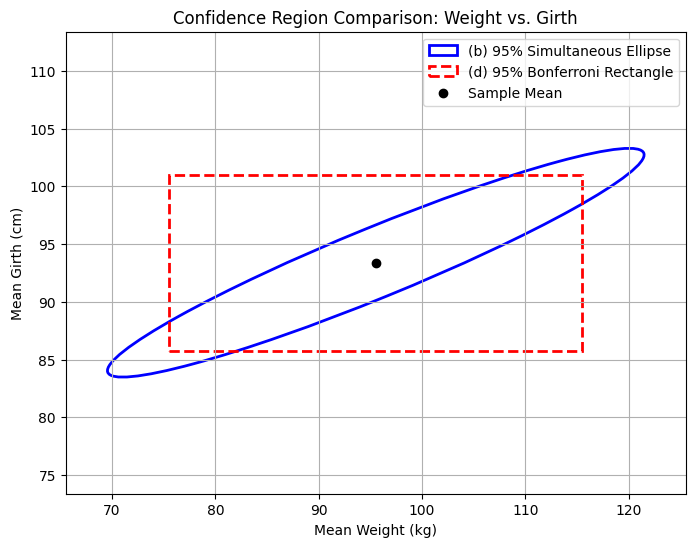


--- (e) Bonferroni CI for (Width - Length) (m=7) ---
CI: [12.49, 13.81]


In [28]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle

# Summary Statistics
n_bears = 61
p_bears = 6
means = np.array([95.52, 164.38, 55.69, 93.39, 17.98, 31.13])
S_bears = np.array([
    [3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37],
    [1343.97, 721.91, 324.25, 537.35, 80.17, 117.73],
    [731.54, 324.25, 179.28, 281.17, 39.15, 56.80],
    [1175.50, 537.35, 281.17, 474.98, 63.73, 94.85],
    [162.68, 80.17, 39.15, 63.73, 9.95, 13.88],
    [238.37, 117.73, 56.80, 94.85, 13.88, 21.26]
])

# Extract Weight (index 0) and Girth (index 3) parameters early for use in plots
mean_wg = np.array([means[0], means[3]])
S_wg = np.array([
    [S_bears[0, 0], S_bears[0, 3]],
    [S_bears[3, 0], S_bears[3, 3]]
])

# (a) Simultaneous Confidence Intervals (Large Sample)
chi2_val = stats.chi2.ppf(0.95, p_bears)
simul_margin = np.sqrt(chi2_val) * np.sqrt(np.diag(S_bears) / n_bears)
print("--- (a) 95% Simultaneous CI ---")
for i, (m, marg) in enumerate(zip(means, simul_margin)):
    print(f"Var {i+1}: [{m - marg:.2f}, {m + marg:.2f}]")

# (b) 95% Simultaneous Confidence Ellipse for Weight and Girth
eigenvalues, eigenvectors = np.linalg.eig(S_wg)
angle = np.degrees(np.arctan2(*eigenvectors[:,0][::-1]))
width, height = 2 * np.sqrt(chi2_val * eigenvalues / n_bears)

fig, ax = plt.subplots(figsize=(8, 6))
ell = Ellipse(xy=mean_wg, width=width, height=height, angle=angle,
              edgecolor='blue', fc='None', lw=2, label='(b) 95% Simultaneous Ellipse')
ax.add_patch(ell)

# (c) Bonferroni Confidence Intervals (m=6)
t_val_m6 = stats.t.ppf(1 - 0.025 / 6, n_bears - 1)
bonf_margin = t_val_m6 * np.sqrt(np.diag(S_bears) / n_bears)
print("\n--- (c) 95% Bonferroni CI (m=6) ---")
for i, (m, marg) in enumerate(zip(means, bonf_margin)):
    print(f"Var {i+1}: [{m - marg:.2f}, {m + marg:.2f}]")

# (d) 95% Bonferroni Rectangle for Weight and Girth (m=6)
rect_x = means[0] - bonf_margin[0]
rect_y = means[3] - bonf_margin[3]
rect_width = 2 * bonf_margin[0]
rect_height = 2 * bonf_margin[3]

rect = Rectangle((rect_x, rect_y), rect_width, rect_height,
                 edgecolor='red', fc='None', lw=2, linestyle='--',
                 label='(d) 95% Bonferroni Rectangle')
ax.add_patch(rect)

ax.scatter(*mean_wg, color='black', label='Sample Mean')
ax.set_xlim(mean_wg[0] - 30, mean_wg[0] + 30)
ax.set_ylim(mean_wg[1] - 20, mean_wg[1] + 20)
ax.set_xlabel('Mean Weight (kg)')
ax.set_ylabel('Mean Girth (cm)')
ax.set_title('Confidence Region Comparison: Weight vs. Girth')
ax.legend()
plt.grid(True)
plt.show()

# (e) Bonferroni CI for Head Width - Head Length (m=7)
diff_mean = means[5] - means[4]
diff_var = (S_bears[5, 5] + S_bears[4, 4] - 2 * S_bears[4, 5]) / n_bears
t_val_m7 = stats.t.ppf(1 - 0.025 / 7, n_bears - 1)
diff_margin = t_val_m7 * np.sqrt(diff_var)
print(f"\n--- (e) Bonferroni CI for (Width - Length) (m=7) ---")
print(f"CI: [{diff_mean - diff_margin:.2f}, {diff_mean + diff_margin:.2f}]")

## 3. Mineral Analysis of Ancient Peruvian Hairs

The dataset tracks Chromium ($x_1$) and Strontium ($x_2$) in parts per million across 9 samples.

**(b) Testing Plausible Values:**
Projecting the joint confidence ellipse onto the axes gives the simultaneous 90% confidence intervals. Based on the data, the CI for Strontium ($x_2$) is approximately $[0.49, 43.14]$. Since 10 falls within this interval, it appears plausible that this Peruvian culture has a mean strontium level of 10.
To test if $\mu_0 = [.30, 10]'$ is a plausible value, we calculate the $T^2$ statistic. The computed $T^2$ is approximately $6.02$, which is less than the critical value of roughly $10.14$. Therefore, $[.30, 10]'$ falls inside the confidence region and is a plausible value for the population mean vector.



**(c) Bivariate Normality:**
Bivariate normality is assessed using Q-Q plots for the marginal distributions and a scatterplot. Extreme values (such as the point with $x_1 = 0.66, x_2 = 78$) deviate significantly from the expected straight line in the Q-Q plot, indicating non-normality. Non-normality inflates the covariance matrix, making the confidence ellipses erroneously large.

**(d) Outlier Removal:**
Removing the outlier creates a significantly tighter confidence ellipse. The inferences change drastically because the sample covariance is highly sensitive to the massive deviations caused by the anomaly.

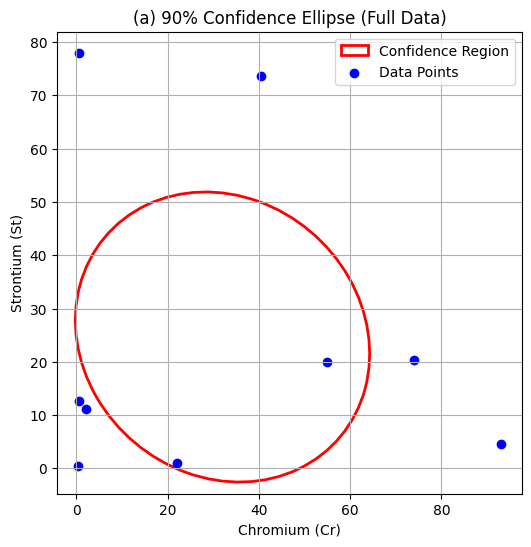

--- (b) Simultaneous 90% CI ---
Chromium (Cr): [-0.21, 64.27]
Strontium (St): [-2.56, 51.86]

T^2 Statistic for [.30, 10]': 10.415
Critical Value: 7.446
Is [.30, 10]' a plausible value? No


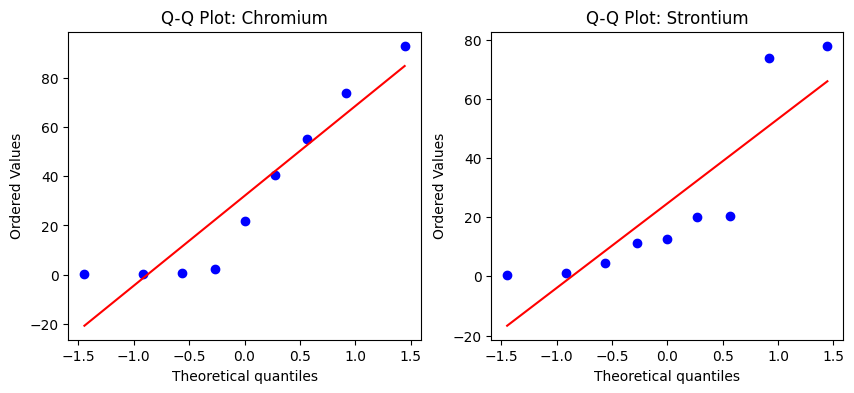

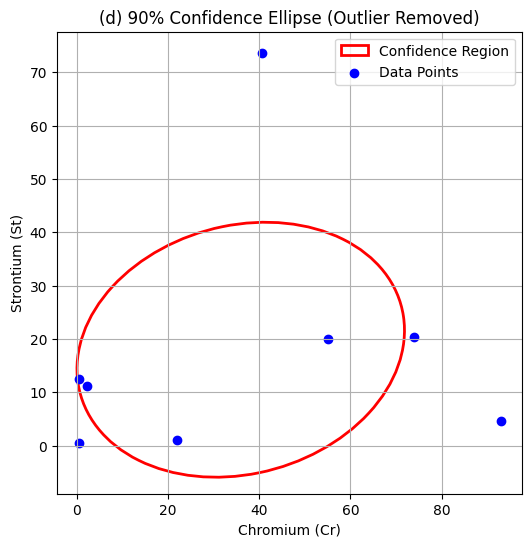

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Data setup
hair_data = pd.DataFrame({
    'Cr': [0.48, 40.53, 2.19, 55, 74, 0.66, 93, 0.37, 22],
    'St': [12.57, 73.68, 11.13, 20.03, 20.29, 78, 4.64, 0.43, 1.08]
})

def plot_ellipse(data, alpha=0.10, title="90% Confidence Ellipse"):
    n, p = data.shape
    x_bar = data.mean().values
    S = data.cov().values

    # Calculate F critical value scaling
    F_val = stats.f.ppf(1 - alpha, p, n - p)
    c_squared = (p * (n - 1) / (n - p)) * F_val

    eigenvalues, eigenvectors = np.linalg.eig(S)
    angle = np.degrees(np.arctan2(*eigenvectors[:,0][::-1]))

    width, height = 2 * np.sqrt(c_squared * eigenvalues / n)

    fig, ax = plt.subplots(figsize=(6, 6))
    ell = Ellipse(xy=x_bar, width=width, height=height, angle=angle,
                  edgecolor='r', fc='None', lw=2, label='Confidence Region')
    ax.add_patch(ell)
    ax.scatter(data.iloc[:, 0], data.iloc[:, 1], c='blue', label='Data Points')
    ax.set_title(title)
    ax.set_xlabel('Chromium (Cr)')
    ax.set_ylabel('Strontium (St)')
    ax.legend()
    plt.grid(True)
    plt.show()

# (a) Plot Ellipse (Full Data)
plot_ellipse(hair_data, title="(a) 90% Confidence Ellipse (Full Data)")

# (b) Simultaneous 90% Confidence Intervals (Projections)
n_hair, p_hair = hair_data.shape
x_bar_hair = hair_data.mean().values
S_hair = hair_data.cov().values

F_crit_hair = stats.f.ppf(0.90, p_hair, n_hair - p_hair)
T2_crit_hair = ((n_hair - 1) * p_hair / (n_hair - p_hair)) * F_crit_hair

margin_hair = np.sqrt(T2_crit_hair) * np.sqrt(np.diag(S_hair) / n_hair)

print("--- (b) Simultaneous 90% CI ---")
print(f"Chromium (Cr): [{x_bar_hair[0] - margin_hair[0]:.2f}, {x_bar_hair[0] + margin_hair[0]:.2f}]")
print(f"Strontium (St): [{x_bar_hair[1] - margin_hair[1]:.2f}, {x_bar_hair[1] + margin_hair[1]:.2f}]")

# Test if [0.30, 10]' is a plausible value
mu_0_hair = np.array([0.30, 10])
diff_hair = x_bar_hair - mu_0_hair
T2_hair = n_hair * diff_hair.T @ np.linalg.inv(S_hair) @ diff_hair

print(f"\nT^2 Statistic for [.30, 10]': {T2_hair:.3f}")
print(f"Critical Value: {T2_crit_hair:.3f}")
print(f"Is [.30, 10]' a plausible value? {'No' if T2_hair > T2_crit_hair else 'Yes'}")
# -----------------------------------

# (c) Q-Q Plots for Normality Check
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(hair_data['Cr'], dist="norm", plot=axs[0])
axs[0].set_title('Q-Q Plot: Chromium')
stats.probplot(hair_data['St'], dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot: Strontium')
plt.show()

# (d) Outlier Removal Analysis (Removing observation 6: 0.66, 78 based on visual inspection)
hair_data_clean = hair_data.drop(5)
plot_ellipse(hair_data_clean, title="(d) 90% Confidence Ellipse (Outlier Removed)")

## 4. Lumber Strength Measurements

This section models $x_1$ (stiffness) and $x_2$ (bending strength) for $n=30$ pieces of lumber[cite: 1].

**(b) Testing "Typical" Values:**
To test if $\mu_{10} = 2000$ and $\mu_{20} = 10000$ are consistent with the data, we calculate the Hotelling's $T^2$ statistic. The computed $T^2$ is roughly $23.65$, which vastly exceeds the critical value of $6.92$. Because the statistic falls well outside the 95% confidence region, the data is **not** consistent with these typical values.

**(c) Viability of Bivariate Normal Model:**
The scatter diagram displays a generally elliptical shape, and the marginal Q-Q plots for Stiffness and Bending Strength show points adhering reasonably well to the theoretical normal line. Furthermore, the Chi-Square Q-Q plot of the squared generalized distances ($d_i^2$) forms a relatively straight line. Together, these graphical analyses confirm that the bivariate normal distribution is a highly viable population model for this lumber dataset.

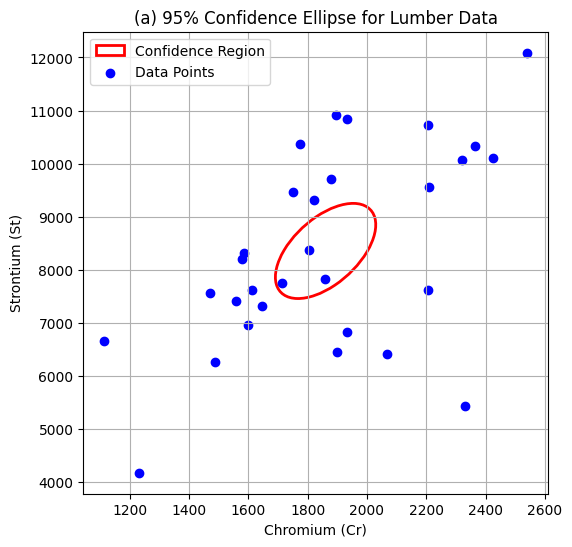

--- (b) Consistency Check ---
T^2 Statistic: 23.648
Critical Value: 6.919
Is [2000, 10000] consistent? No (Reject)


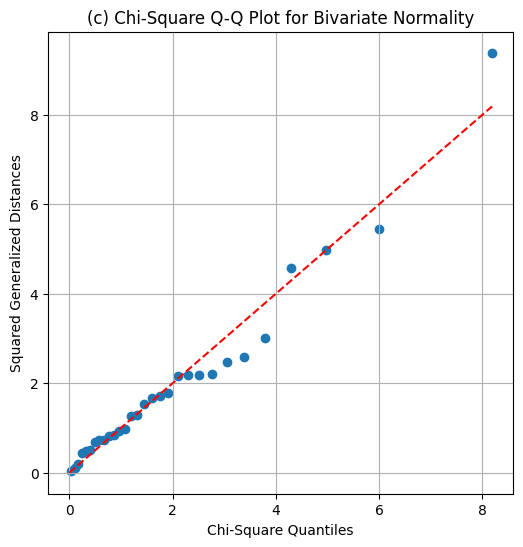

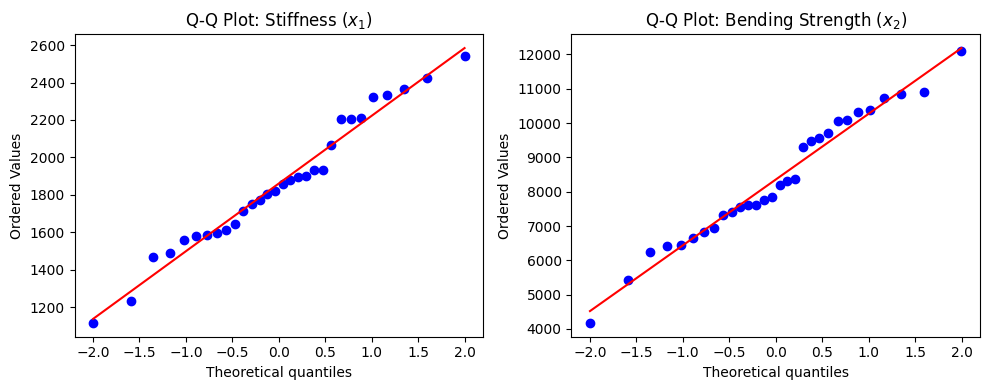

In [31]:
# Data setup (30 observations)
lumber_data = np.array([
    [1232, 4175], [1115, 6652], [2205, 7612], [1897, 10914], [1932, 10850],
    [1612, 7627], [1598, 6954], [1804, 8365], [1752, 9469], [2067, 6410],
    [2365, 10327], [1646, 7320], [1579, 8196], [1880, 9709], [1773, 10370],
    [1712, 7749], [1932, 6818], [1820, 9307], [1900, 6457], [2426, 10102],
    [1558, 7414], [1470, 7556], [1858, 7833], [1587, 8309], [2208, 9559],
    [1487, 6255], [2206, 10723], [2332, 5430], [2540, 12090], [2322, 10072]
])

df_lumber = pd.DataFrame(lumber_data, columns=['Stiffness', 'Bending_Strength'])

# (a) Confidence Ellipse
plot_ellipse(df_lumber, alpha=0.05, title="(a) 95% Confidence Ellipse for Lumber Data")

# (b) Consistency Check for mu_0 = [2000, 10000]
n, p = df_lumber.shape
mu_0_lumber = np.array([2000, 10000])
x_bar_lumber = df_lumber.mean().values
S_lumber = df_lumber.cov().values

diff_lumber = x_bar_lumber - mu_0_lumber
T2_lumber = n * diff_lumber.T @ np.linalg.inv(S_lumber) @ diff_lumber

F_crit_lumber = stats.f.ppf(0.95, p, n - p)
T2_crit_lumber = ((n - 1) * p / (n - p)) * F_crit_lumber

print(f"--- (b) Consistency Check ---")
print(f"T^2 Statistic: {T2_lumber:.3f}")
print(f"Critical Value: {T2_crit_lumber:.3f}")
print(f"Is [2000, 10000] consistent? {'No (Reject)' if T2_lumber > T2_crit_lumber else 'Yes (Fail to Reject)'}")

# (c) Chi-Square Q-Q Plot for Bivariate Normality
d_squared = []
S_inv_lumber = np.linalg.inv(S_lumber)
for row in lumber_data:
    diff_i = row - x_bar_lumber
    d_squared.append(diff_i.T @ S_inv_lumber @ diff_i)

d_squared.sort()
chi2_quantiles = stats.chi2.ppf((np.arange(1, n + 1) - 0.5) / n, df=p)

plt.figure(figsize=(6, 6))
plt.scatter(chi2_quantiles, d_squared)
plt.plot([0, max(chi2_quantiles)], [0, max(chi2_quantiles)], color='red', linestyle='--')
plt.title("(c) Chi-Square Q-Q Plot for Bivariate Normality")
plt.xlabel("Chi-Square Quantiles")
plt.ylabel("Squared Generalized Distances")
plt.grid(True)
plt.show()

# Marginal Q-Q Plots for Lumber Data
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(df_lumber['Stiffness'], dist="norm", plot=axs[0])
axs[0].set_title('Q-Q Plot: Stiffness ($x_1$)')
stats.probplot(df_lumber['Bending_Strength'], dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot: Bending Strength ($x_2$)')
plt.tight_layout()
plt.show()
# ------------------------------------------------